Packages installed.
📤 Upload resume file


Saving KratiPatidar.pdf to KratiPatidar (1).pdf
📤 Upload job description file


Saving college-intern-v1.pdf to college-intern-v1 (4).pdf

✅ Files uploaded & text extracted successfully!

Final Result
------------
Score: 78.75 / 100
Stage: Prepared
Good alignment, minor gaps

Note:
Score reflects readiness for this role, not overall capability.

Strengths:
- css
- java
- html

Areas to improve:
- javascript

Optional learning areas:


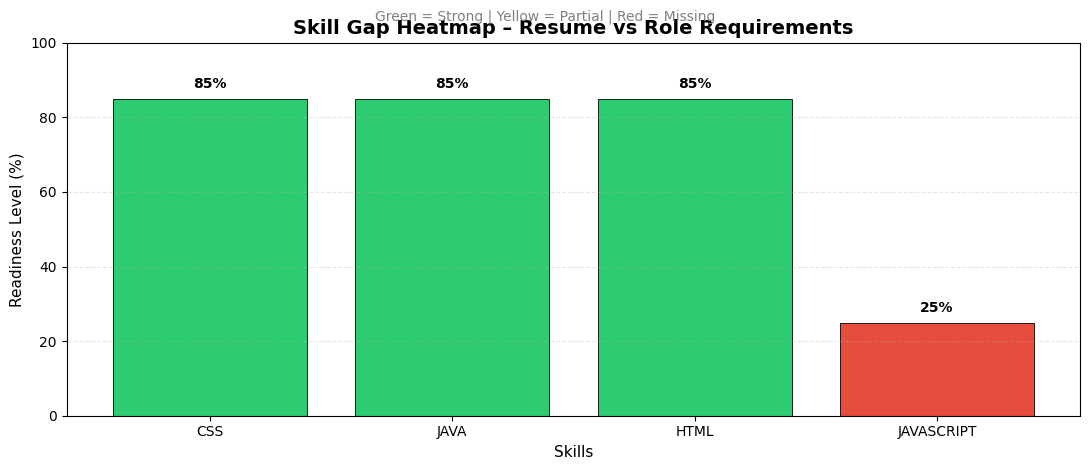

In [ ]:
"""
================================================================================
Resume–JD Matching and Readiness Scoring Engine
================================================================================
This notebook evaluates how well a resume aligns with a specific job description.
The score reflects readiness for the selected role, not overall ability.
"""

# =============================================================================
# CELL 1: INSTALLATION
# =============================================================================

!pip install -q sentence-transformers PyPDF2 python-docx scikit-learn numpy

print("Packages installed.")

# =============================================================================
# CELL 2: CONFIGURATION
# =============================================================================

SCORING_WEIGHTS = {
    'skill_match': 0.45,
    'experience_fit': 0.25,
    'project_relevance': 0.20,
    'bonus_signals': 0.10
}

MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'

# =============================================================================
# CELL 3: FILE UPLOAD & TEXT EXTRACTION
# =============================================================================

from google.colab import files
import PyPDF2
import docx
import re
import numpy as np
import matplotlib.pyplot as plt

def extract_text(file_path):
    if file_path.endswith(".pdf"):
        text = ""
        with open(file_path, "rb") as f:
            reader = PyPDF2.PdfReader(f)
            for page in reader.pages:
                text += page.extract_text() + "\n"
        return text

    if file_path.endswith(".docx"):
        doc = docx.Document(file_path)
        return "\n".join([p.text for p in doc.paragraphs])

    if file_path.endswith(".txt"):
        return open(file_path).read()

    return ""

print("📤 Upload resume file")
resume_file = files.upload()
resume_path = list(resume_file.keys())[0]

print("📤 Upload job description file")
jd_file = files.upload()
jd_path = list(jd_file.keys())[0]

resume_text = extract_text(resume_path)
jd_text = extract_text(jd_path)

print("\n✅ Files uploaded & text extracted successfully!")

# =============================================================================
# CELL 4: PARSERS
# =============================================================================

class ResumeParser:
    def parse(self, text):
        skills = re.findall(
            r'\b(python|java|javascript|sql|html|css|pandas|numpy|scikit-learn|tensorflow|git)\b',
            text.lower()
        )
        return {
            "skills": list(set(skills)),
            "experience_years": self._years(text),
            "projects": self._projects(text),
            "certifications": self._certs(text)
        }

    def _years(self, text):
        m = re.search(r'(\d+)\s+years', text.lower())
        return float(m.group(1)) if m else 0.0

    def _projects(self, text):
        return [l for l in text.split("\n") if len(l) > 30][:5]

    def _certs(self, text):
        return [l for l in text.split("\n") if "cert" in l.lower()]

class JDParser:
    def parse(self, text):
        return {
            "required_skills": re.findall(
                r'\b(python|java|javascript|sql|pandas|numpy|scikit-learn|html|css)\b',
                text.lower()
            ),
            "preferred_skills": re.findall(
                r'\b(tensorflow|mlops|docker|git)\b',
                text.lower()
            ),
            "min_experience": self._years(text),
            "role_level": self._level(text)
        }

    def _years(self, text):
        m = re.search(r'(\d+)\+?\s*years', text.lower())
        return float(m.group(1)) if m else 0.0

    def _level(self, text):
        t = text.lower()
        if "intern" in t:
            return "intern"
        if "entry" in t:
            return "junior"
        if "mid" in t:
            return "mid"
        return "senior"

# =============================================================================
# CELL 5: SCORING ENGINE
# =============================================================================

class ScoringEngine:
    def __init__(self, weights):
        self.weights = weights

    def final_score(self, scores):
        total = sum(scores[k] * self.weights[k] for k in scores)

        if total >= 80:
            level, msg = "Highly Prepared", "Strong alignment with this role"
        elif total >= 65:
            level, msg = "Prepared", "Good alignment, minor gaps"
        elif total >= 45:
            level, msg = "Developing Readiness", "Basic alignment, needs improvement"
        else:
            level, msg = "Preparation Stage", "This role has higher expectations"

        return round(total, 2), level, msg

# =============================================================================
# CELL 6: MAIN MATCHER
# =============================================================================

class ResumeJDMatcher:
    def __init__(self):
        self.resume_parser = ResumeParser()
        self.jd_parser = JDParser()
        self.scorer = ScoringEngine(SCORING_WEIGHTS)

    def match(self, resume_text, jd_text):
        r = self.resume_parser.parse(resume_text)
        j = self.jd_parser.parse(jd_text)

        matched = list(set(r["skills"]) & set(j["required_skills"]))
        missing = list(set(j["required_skills"]) - set(r["skills"]))
        optional = list(set(j["preferred_skills"]) - set(r["skills"]))

        skill_score = (len(matched) / max(len(j["required_skills"]), 1)) * 100
        exp_score = 100 if r["experience_years"] >= j["min_experience"] else max(30, 100 - (j["min_experience"] * 20))
        project_score = 70 if r["projects"] else 20
        bonus_score = 60 if r["certifications"] else 30

        scores = {
            "skill_match": skill_score,
            "experience_fit": exp_score,
            "project_relevance": project_score,
            "bonus_signals": bonus_score
        }

        final, level, msg = self.scorer.final_score(scores)

        return {
            "final_score": final,
            "readiness_level": level,
            "summary": msg,
            "strengths": matched if matched else [],
            "focus_areas": missing,
            "optional_growth": optional,
            "scores": scores
        }

    def print_report(self, report):
        print("\nFinal Result")
        print("------------")
        print(f"Score: {report['final_score']} / 100")
        print(f"Stage: {report['readiness_level']}")
        print(report["summary"])

        print("\nNote:")
        print("Score reflects readiness for this role, not overall capability.")

        print("\nStrengths:")
        for s in report["strengths"] or ["Foundational skills developing"]:
            print("-", s)

        print("\nAreas to improve:")
        for s in report["focus_areas"] or ["No critical gaps identified"]:
            print("-", s)

        print("\nOptional learning areas:")
        for s in report["optional_growth"]:
            print("-", s)


# =============================================================================
# SKILL GAP HEATMAP
# =============================================================================

import matplotlib.pyplot as plt

def plot_skill_gap_heatmap(strengths, missing, optional):
    """
    Visual diagnostic chart explaining skill readiness.
    Designed to be judge-friendly and presentation-ready.
    """

    skills = []
    scores = []
    colors = []

    for s in strengths:
        skills.append(s.upper())
        scores.append(85)
        colors.append("#2ecc71")  # soft green

    for s in optional:
        skills.append(s.upper())
        scores.append(55)
        colors.append("#f1c40f")  # soft yellow

    for s in missing:
        skills.append(s.upper())
        scores.append(25)
        colors.append("#e74c3c")  # soft red

    if not skills:
        print("No skills available for visualization.")
        return

    # Sort by score (high → low)
    combined = sorted(zip(skills, scores, colors), key=lambda x: x[1], reverse=True)
    skills, scores, colors = zip(*combined)

    plt.figure(figsize=(11, 5))
    bars = plt.bar(skills, scores, color=colors, edgecolor="black", linewidth=0.6)

    # Add value labels
    for bar, score in zip(bars, scores):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            score + 2,
            f"{score}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    plt.ylim(0, 100)
    plt.ylabel("Readiness Level (%)", fontsize=11)
    plt.xlabel("Skills", fontsize=11)

    plt.title(
        "Skill Gap Heatmap – Resume vs Role Requirements",
        fontsize=14,
        fontweight="bold"
    )

    plt.suptitle(
        "Green = Strong | Yellow = Partial | Red = Missing",
        fontsize=10,
        color="gray",
        y=0.93
    )

    plt.grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()


# =============================================================================
# CELL 8: RUN SYSTEM
# =============================================================================

matcher = ResumeJDMatcher()
report = matcher.match(resume_text, jd_text)
matcher.print_report(report)

plot_skill_gap_heatmap(
    report["strengths"],
    report["focus_areas"],
    report["optional_growth"]
)
